# 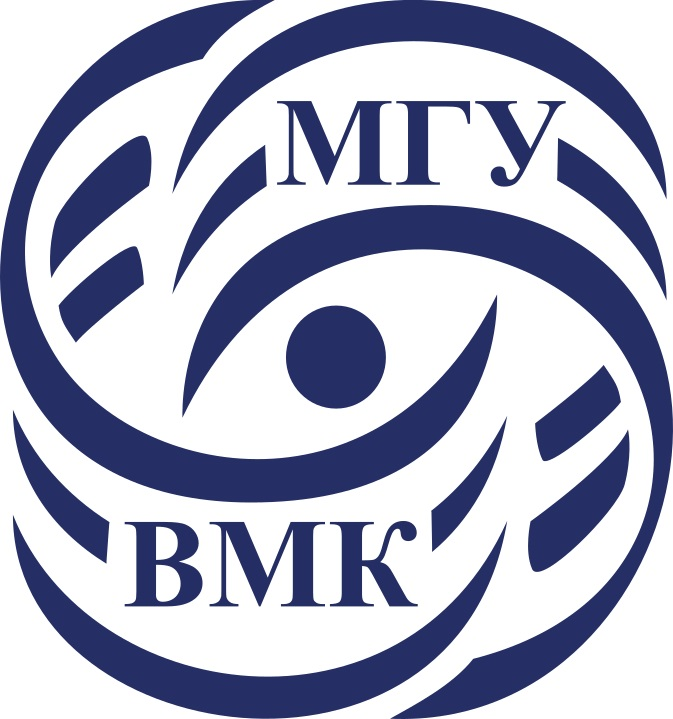

# Машинное обучение. ВМК МГУ

# Практическое задание 7: SVM
## Уровень: <font color='SkyBlue'>**Базовый (Base)**</font>

# О формате сдачи

🔷 **<font color='plum'>При решении ноутбука используйте данный шаблон</font>**

    ✅ Можно добавлять новые ячейки любых типов
    ❌ Не нужно удалять текстовые ячейки c разметкой частей ноутбука и формулировками заданий


🔷 **<font color='plum'>При оценивании задач учитывается код</font>**

    ✅ Задания, в которых необходим код, обычно помечаются фразами "Your code here"/"Ваш код" и аналогичными
    ❌ Ответы на вопросы без сопутствующего кода оцениваются в 0 баллов
    ❌ Наличе работоспособного кода в ноутбуке, если на сказано иного, обязательно

🔷 **<font color='plum'>При оценивании задач учитываются выводы</font>**

    ✅ Задания, в которых необходимы выводы, обычно помечаются фразами Вывод"/"Ответ на вопрос"/"Ваш текст" и аналогичными
    ✅ Обычно выводы подразумевают под собой текстовый ответ (можно писать markdown, latex).
    ✅ Сопутствующие изображения, графики, таблички - приветствуются!
    ❌ При отсутствии выводов задание не засчитается на полный балл

Цель данного задания:

* Изучите работу модели SVM
* Поймете, как с её помощью можно строить нелинейные разделяющие поверхности
* Потренируетесь в подборе оптимальных параметров на обучающей выборке для достижения наилучшего качества на закрытой выборке (ML-решение)

-------
<font color="white" style="opacity:0.2025"></font>
<font color=DarkOrange>**Примерное время выполнения (execution time/время выполнения, если нажать run all) всех ячеек ноутбука при правильной реализации: до 10 минут </font>**

# Подготовка рабочей среды

Сначала установим нужные нам версии библиотек. Мы гарантируем, что в данных версиях задание будет корректно отрабатывать.

После установки нужных версий, **возможно,** нужно перезагрузить среду (runtime), но скорее всего вам это не понадобится


На скачивание файла и установку понадобится не более 5 минут.

<font color='OrangeRed'>**Важно!**</font>

Устанавливать нужные версии нужно каждый раз, когда создается новый рантайм. Например, если вы 2 часа подряд делаете это задание, то подготовить библиотеки достаточно 1 раз. Но если вы, например, начали в понедельник, затем закрыли/выключили ноутбук, то при продолжении в среду, вам нужно будет запустить рантайм заново и следовательно заново установить библиотеки.

<font color='OrangeRed'>**Важно!**</font>
Если вы предпочитаете делать практические задания на своем личном ноутбуке, то проверьте, что вы установили рабочее окружение в [соответствии с гайдом](https://github.com/MSU-ML-COURSE/ML-COURSE-24-25/blob/main/tutorials/%D0%A2%D1%83%D1%82%D0%BE%D1%80%D0%B8%D0%B0%D0%BB%20%D0%BF%D0%BE%20%D1%83%D1%81%D1%82%D0%B0%D0%BD%D0%BE%D0%B2%D0%BA%D0%B5%20%D1%80%D0%B0%D0%B1%D0%BE%D1%87%D0%B5%D0%B3%D0%BE%20%D0%BE%D0%BA%D1%80%D1%83%D0%B6%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B2%20Python%20%D0%B4%D0%BB%D1%8F%20%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F%20%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%20(2).pdf)


In [129]:
! curl https://raw.githubusercontent.com/MSU-ML-COURSE/ML-COURSE-25-26/refs/heads/master/requirements/requirements.txt -o ./requirements_2025_26_for_colab_small.txt
! pip install -q -r ./requirements_2025_26_for_colab_small.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   360  100   360    0     0   1158      0 --:--:-- --:--:-- --:--:--  1161


Проверим версию библиотеки:

In [130]:
import catboost
assert(catboost.__version__ == '1.2.8')

Теперь можно приступать к выполнению задания! :)

-----------
<font color="white" style="opacity:0.2025"></font>

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from copy import copy

Если Вы дальтоник, то можете воспользоваться готовой colormap из matplotlib (или найти свою):
```
plt.style.use('tableau-colorblind10')
```

Приведем вспомогательный код

In [132]:
from matplotlib.colors import ListedColormap

from sklearn.svm import LinearSVC, SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate, train_test_split
from sklearn.metrics import make_scorer, accuracy_score, roc_auc_score
from sklearn.datasets import make_blobs, make_circles, make_moons

In [133]:
def make_moons_cls(size=1000, d=2):
    X, y = make_moons(n_samples=size, noise=0.15)
    if d > 2:
        X = np.concatenate((X, np.random.normal(size=(size, d-2))), axis=1)
    return X, y

def make_circles_cls():
    X, y = make_circles()

def generate_data_with_imb_classes(size1=100, size2=10):
    X = np.r_[(
        np.random.normal(loc=1.0, size=(size1, 2)),
        np.random.normal(loc=0.5, size=(size2, 2))
    )]

    y = np.ones(len(X))
    y[-size2:] = 0
    return X, y

In [134]:
def plot_separating_surface(X, y, cls, view_support=False, title=''):
    x_min = min(X[:, 0]) - 0.1
    x_max = max(X[:, 0]) + 0.1
    y_min = min(X[:, 1]) - 0.1
    y_max = max(X[:, 1]) + 0.1
    h = 0.005
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(['#FF0000', '#0000FF'])

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))
    Z = cls.predict(np.c_[xx.ravel(), yy.ravel()])

    plt.figure(figsize=(10, 10))
    if title:
        plt.title(title)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=40, cmap=cm_bright)
    if view_support:
        plt.scatter(X[cls.support_, 0], X[cls.support_, 1],
                    c=y[cls.support_], edgecolors='k', s=150, cmap=cm_bright)
    Z = Z.reshape(xx.shape)
    plt.xticks(())
    plt.yticks(())
    plt.contourf(xx, yy, Z, cmap=cm, alpha=.3)
    plt.show()

# Загрузка данных

In [135]:
import gdown
gdown.download_folder('https://drive.google.com/drive/folders/1bp39_Jj0edo1lzxZ3DIoChsOVy5DVi1R?usp=sharing')

Retrieving folder contents


Retrieving folder 1tv605hGxdQtd4zC787DbcRF0312gDeK_ imbalanced
Processing file 14zd2xHDChSHtMWQ_TUzM8td7s8gzCO2u X_imb_test.npz.npy
Processing file 1Qed066d3gUsUOZiUZu6aCrIH9f0yWKSc X_imb.npz.npy
Processing file 1uD87Xbh4MMBBn5fsScrknI54SINIqory y_imb_test.npz.npy
Processing file 1RR2VU_6WJMLo88k8C1VzBwb2Ibnz1yJf y_imb.npz.npy
Retrieving folder 1uoI6vZWwIII1jd2k5TtsZTJ3JOkK0G6O public
Processing file 1Win7ZtHLHEbDtX6x6O7vBJHwJviQxbp5 cX_test.npy
Processing file 1MowPnLFAMEjjcAjDA4skE4OUFdmaiSY6 cX_train.npy
Processing file 1VYA4N5wCQhwteQSZkDogFTha2xRv0FgW cy_train.npy


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=14zd2xHDChSHtMWQ_TUzM8td7s8gzCO2u
To: /home/tepumasuta/devs/university/sem 5/ml/task7/base/05-SVM/imbalanced/X_imb_test.npz.npy
100%|██████████| 2.05k/2.05k [00:00<00:00, 5.08MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Qed066d3gUsUOZiUZu6aCrIH9f0yWKSc
To: /home/tepumasuta/devs/university/sem 5/ml/task7/base/05-SVM/imbalanced/X_imb.npz.npy
100%|██████████| 2.05k/2.05k [00:00<00:00, 5.70MB/s]
Downloading...
From: https://drive.google.com/uc?id=1uD87Xbh4MMBBn5fsScrknI54SINIqory
To: /home/tepumasuta/devs/university/sem 5/ml/task7/base/05-SVM/imbalanced/y_imb_test.npz.npy
100%|██████████| 1.09k/1.09k [00:00<00:00, 4.19MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RR2VU_6WJMLo88k8C1VzBwb2Ibnz1yJf
To: /home/tepumasuta/devs/university/sem 5/ml/task7/base/05-SVM/imbalanced/y_imb.npz.npy
100%|██████████| 1.09k/1.0

['/home/tepumasuta/devs/university/sem 5/ml/task7/base/05-SVM/imbalanced/X_imb_test.npz.npy',
 '/home/tepumasuta/devs/university/sem 5/ml/task7/base/05-SVM/imbalanced/X_imb.npz.npy',
 '/home/tepumasuta/devs/university/sem 5/ml/task7/base/05-SVM/imbalanced/y_imb_test.npz.npy',
 '/home/tepumasuta/devs/university/sem 5/ml/task7/base/05-SVM/imbalanced/y_imb.npz.npy',
 '/home/tepumasuta/devs/university/sem 5/ml/task7/base/05-SVM/public/cX_test.npy',
 '/home/tepumasuta/devs/university/sem 5/ml/task7/base/05-SVM/public/cX_train.npy',
 '/home/tepumasuta/devs/university/sem 5/ml/task7/base/05-SVM/public/cy_train.npy']

<h1><font color="red">**!!! Пришлось вырезать результаты запуска CV, так как файл занимал 18 МБ...**</font></h1>

# SVM и разделяющая поверхность

На лекции вы изучили, что линейная, с виду, модель SVM, при помощи некоторых "фокусов", называемых ядрами, умеет строить нелинейные поверхности. В данном ноутбуке посмотрим, как это все работает на практике, и какие гиперпараметры настройки у этого метода есть.

<font color='MediumTurquoise'>**Историческая справка:**</font> Метод опорных векторов (SVM) стал популярным в 90-х годах, особенно с 1995 года, благодаря своей эффективности в задачах классификации и способности обрабатывать высокоразмерные данные. Он также привлек внимание благодаря использованию ядровых функций, что позволяло решать нелинейные задачи. Однако с появлением более сложных методов, таких как глубокое обучение, и увеличением объема данных, SVM стал менее популярным, поскольку более современные алгоритмы демонстрировали лучшие результаты на больших наборах данных и обеспечивали более простую настройку.

## <font color='DarkOrange'>**Задание 1 [1 балл]**</font>


В ячейке ниже генерируется выборка, состоящая из объектов двух классов. Каждый объект представлен двумя координатами, так что объекты этой выборки можно отобразить на плоскости, используя функцию scatter из библиотеки matplotlib.


    
В этом задании вам надо будет обучить линейную разделяющую поверхность с помощью ```sklearn.svm.SVC(kernel='linear')```, а также нелинейную c rbf-ядром с помощью ```sklearn.svm.SVC(kernel='rbf')```. Остальные параметры методов можете оставить дефолтными. Делить выборку на обучение и валидацию сейчас не требуется, так как нас будет пока интересовать только форма разделяющей кривой.

In [136]:
X, y = make_moons_cls()
linear_svc = SVC(kernel='linear')
nonlinear_svc = SVC(kernel='rbf')

Визуализируем выборку

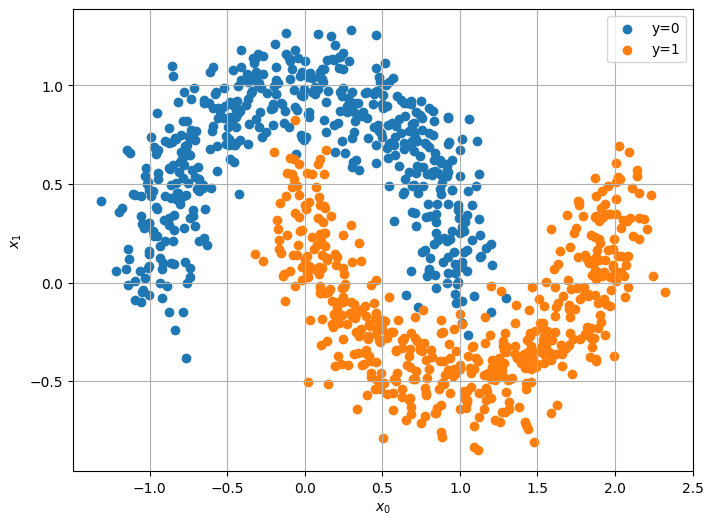

In [137]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label='y=0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='y=1')
plt.xlabel('$x_0$')
plt.ylabel('$x_1$')
plt.legend()
plt.grid()

Обучите модели и визуализируйте разделяющую поверхность для обеих моделей с помощью функции plot_separating_surface(). Посчитайте точность (accuracy) на обучающей выборке для каждой из моделей.

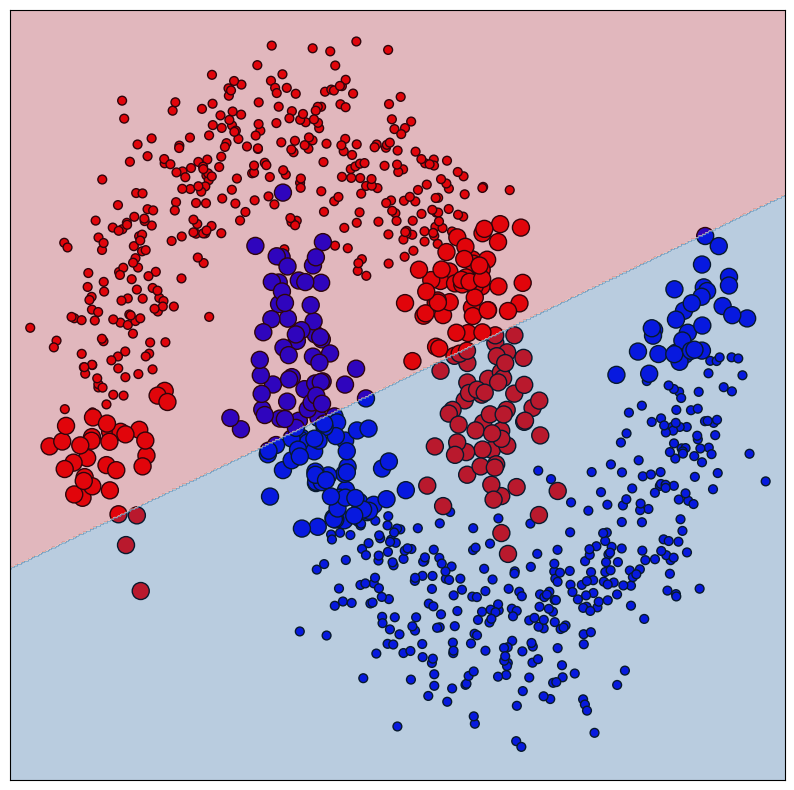

Train Accuracy (linear): 0.877


In [138]:
# Your code here
linear_svc.fit(X, y)
plot_separating_surface(X, y, linear_svc, True)
print(f'Train Accuracy (linear): {accuracy_score(y, linear_svc.predict(X)):.3f}')

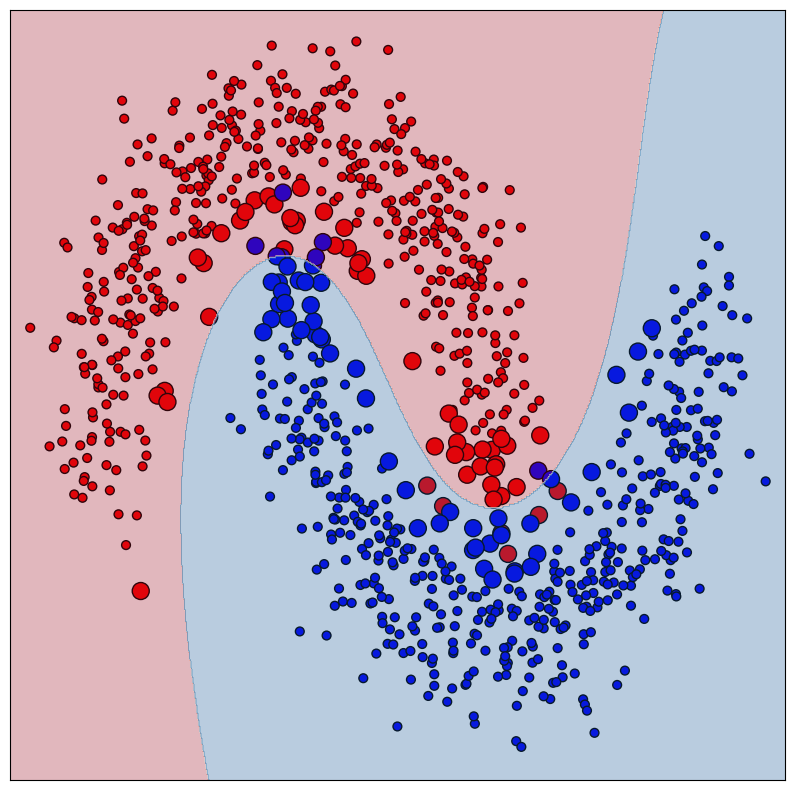

Train Accuracy (non linear): 0.988


In [139]:
# Your code here
nonlinear_svc.fit(X, y)
plot_separating_surface(X, y, nonlinear_svc, True)
print(f'Train Accuracy (non linear): {accuracy_score(y, nonlinear_svc.predict(X)):.3f}')

**Сделайте вывод**
о получившихся результатах. Какая из моделей лучше подходит для данной выборки и почему?

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Ну лучше конечно же нелийнейная, т.к. классы линейно неразделимы, так надо разделять например кубической кривой, но можно любой параметрической кривой с достаточным числом степеней свободы. По факту, линейная модель минимизировала число точек другого класса внутри класса (т.е. количество синих точек для красной части и наоборот) с точки зрения разделяющей поверхности

## 2. Опорные объекты

Продолжаем работать с выборкой и моделями из первой части. Для линейной и rbf-моделей рассмотрим
    опорные объекты, полученные после обучения. Визуализировать их можно, используя функуцию plot_separating_surface с параметром vis_support=True. Достанем опорные объекты из обученной модели с помощью поля model.support_.

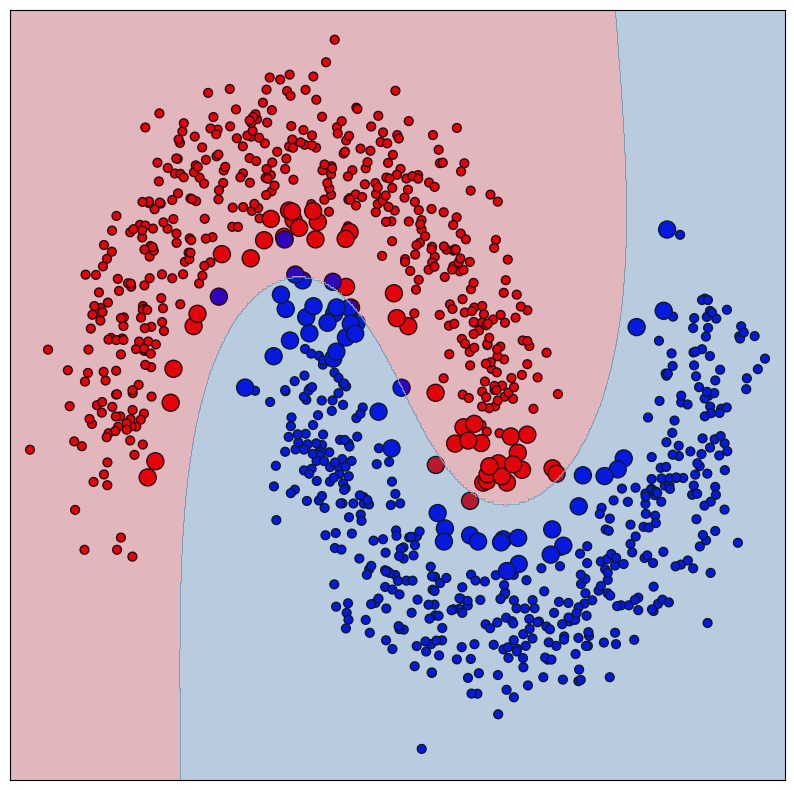

In [93]:
plot_separating_surface(X, y, nonlinear_svc, view_support=True)

Обучим новые две модели ```SVC(kernel='rbf')```, используя только опорные объекты построенные с помощью соответственно линейной (linear_svc) и нелинейной (nonlinear_svc) моделей из первой части.

In [94]:
# Учим модели только на опорных объектах
svc_on_linear_support = SVC(kernel='rbf').fit(X[linear_svc.support_, :], y[linear_svc.support_])
svc_on_rbf_support = SVC(kernel='rbf').fit(X[nonlinear_svc.support_, :], y[nonlinear_svc.support_])

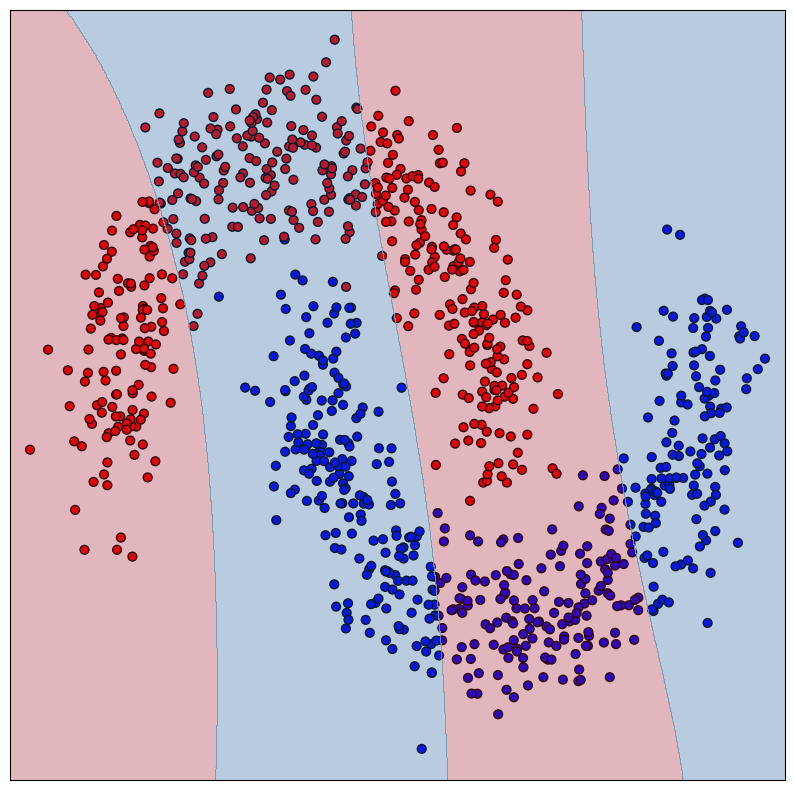

In [95]:
plot_separating_surface(X, y, svc_on_linear_support)

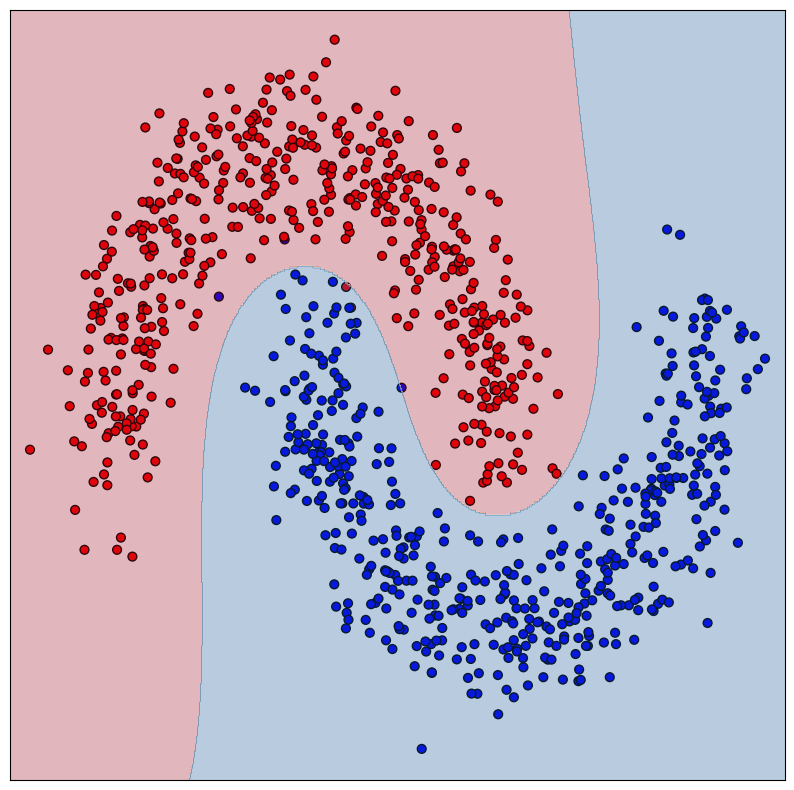

In [96]:
plot_separating_surface(X, y, svc_on_rbf_support)

### <font color='DarkOrange'>**Задание 2 [1 балл]**</font>

Сравните полученные разделяющие поверхности с нелинейной моделью (nonlinear_svc) из задания 1. Какая из поверхностей больше похожа на нелинейнную модель из первой части и почему, опишите в выводе.


<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Ну конечно вторая, в первой неправильные опорные вектора, они не ту функцию минимизируют, это как взять неправильные данные для mesh-а и натянуть на них текстуру с другой вообще структурой, это доставит много приятных минут отладки, мы знаем, что для построения модели методом опорных векторов нам нужны только опорные вектора и вектора ошибки, но лишь при условии, что они от правильной модели. Линейная поверхность на своих опорных векторах была бы правильной, хоть и плохой

---

Теперь обучим модель ```SVC(kernel='rbf')```, используя все объекты кроме тех, что являлись опорными для нелинейной модели из первой части (nonlinear_svc) и сравним эту модель вместе с svc_on_rbf_support с нелинейной моделью из задания 1(nonlinear_svc). Визуализируйте разделяющие поверхности обеих моделей.

In [97]:
non_support_vectors = [i for i in range(len(X)) if i not in nonlinear_svc.support_]
svc_all_without_rbf_support = SVC(kernel='rbf').fit(X[non_support_vectors, :], y[non_support_vectors])

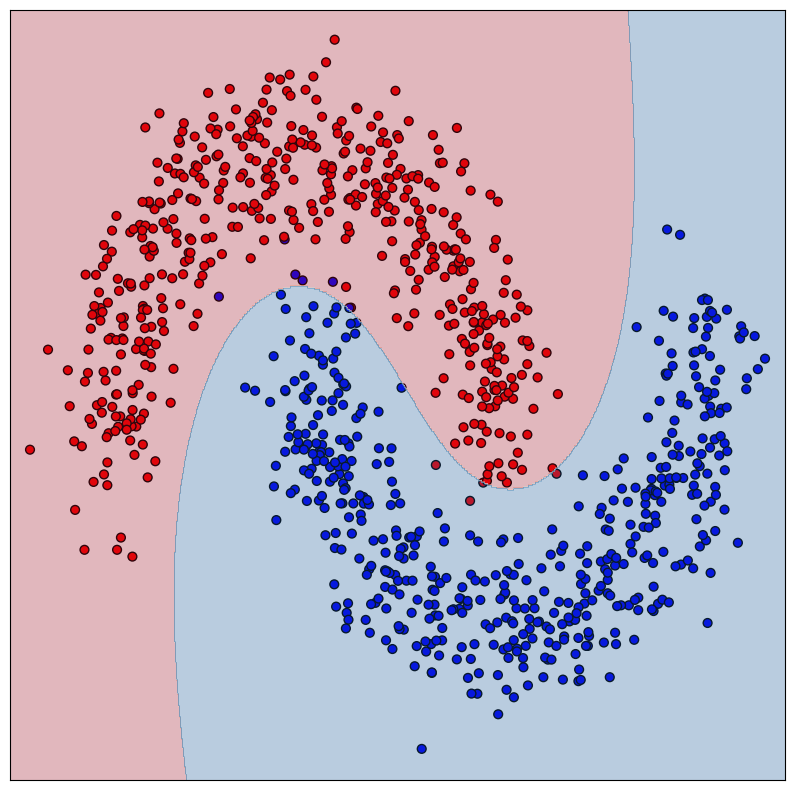

In [98]:
plot_separating_surface(X, y, svc_all_without_rbf_support)

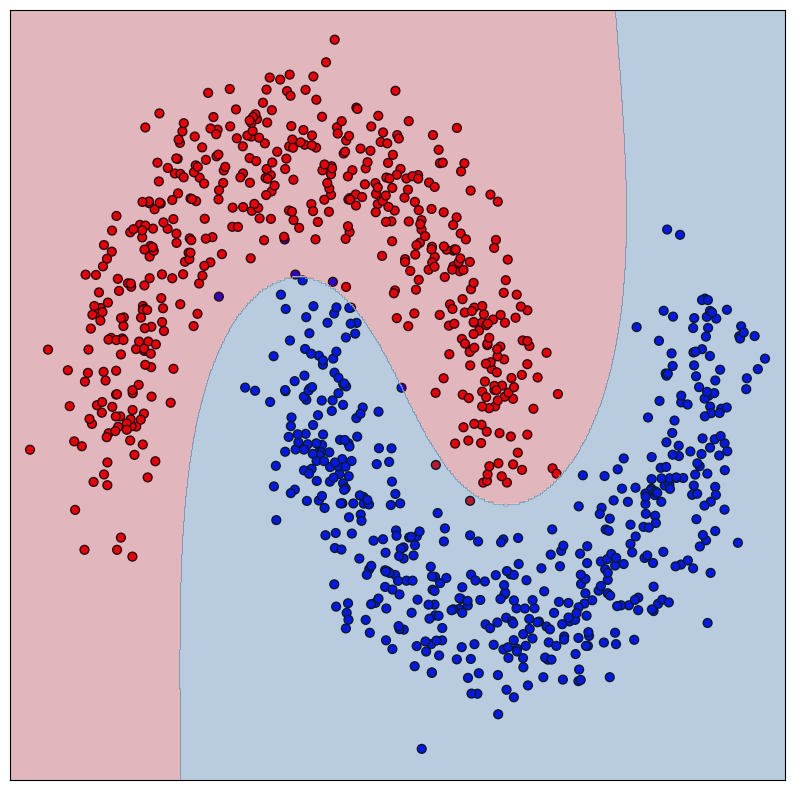

In [99]:
plot_separating_surface(X, y, nonlinear_svc)

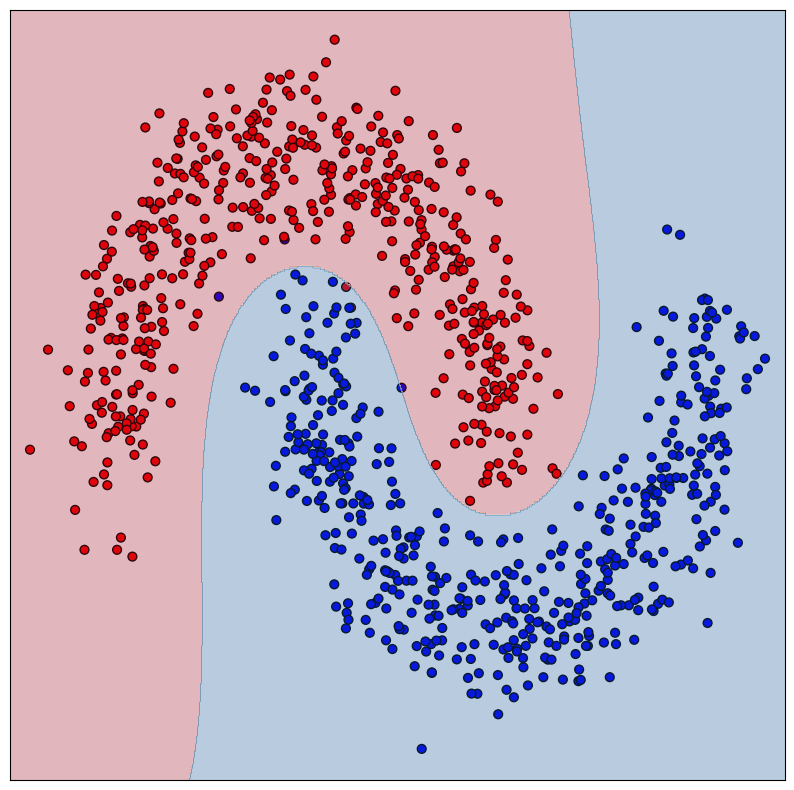

In [100]:
plot_separating_surface(X, y, svc_on_rbf_support)

### <font color='DarkOrange'>**Задание 3 [1.5 баллa]**</font>

**Сделайте вывод:** Сильно ли полученные поверхности отличаются от той, что была получена в первом задании? Что произошло с пограничными объектами? Объясните полученные результаты.

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Отличается не сильно, дело в том, что у нас на границе многовато в целом шума, поэтому убрав часть из него &mdash; да у нас поменялись сами опорные вектора, но засчёт гипотезы о компактности, у нас рядом много похожих наблюдений, и уже на основании них была построена новая граница, они не сильно отличаются от положения старых, если подумать, что старые были на границе скорее всего из-за шума. Ну то есть, суммарно убрав границу от множества у нас так как множество было примерно равномерно заполнено удалив границы в целом его форма останется такой же, а значит новая граница будет с чуть большим отступом, но примерно там же

# 4. Обучите лучшую SVM модель (ML-решение)

Возможность строить нелинейные поверхности может сильно улучшить качество, но и несет риск переобучения.
    В этом задании предстоит обучить лучшую svm модель и получить хорошее качество на тесте в системе тестирования. Для контроля переобучения рекомендуется пользоваться кросс-валидацией. Для улучшения качества рекомендуется подбирать

1. параметр регуляризации C;
2. тип разделяющей кривой linear/rbf/poly;
3. степень в случае разделяющей кривой poly.

Также не забывайте, что при решении задач машинного обучения полезно смотреть в данные :)

Все csv-таблицы с данными вы можете взять из публичного теста, который также есть в проверяющей системе. Для этого распакуйте архив с публичными тестами и положите файлы в рабочей директории (рядом с ноутбуком)

In [101]:
X_train = np.load('05-SVM/public/cX_train.npy')
y_train = np.load('05-SVM/public/cy_train.npy')
X_test = np.load('05-SVM/public/cX_test.npy')

In [102]:
X_train.shape, y_train.shape, X_test.shape

((800, 5), (800,), (200, 5))

In [103]:
X = X_train
y = y_train.ravel()

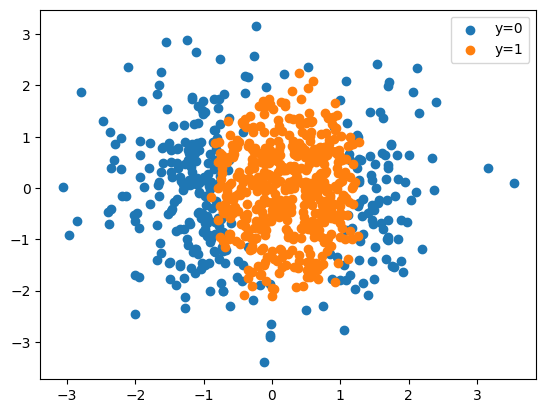

In [104]:
plt.scatter(X[y == 0, 4], X[y == 0, 3], label='y=0')
plt.scatter(X[y == 1, 4], X[y == 1, 3], label='y=1')
plt.legend()

In [105]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score


In [ ]:

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', 'passthrough'),
    ('dim_reduction', 'passthrough'),
    ('svm', SVC())
])

param_grid_svm = [
    {
        'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler(), PowerTransformer(method='yeo-johnson'), 'passthrough'],
        'feature_selection': ['passthrough'],
        'dim_reduction': ['passthrough'],
        'svm__C': [0.01, 0.1, 1, 10, 100],
        'svm__kernel': ['linear'],
    },
    {
        'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler(), PowerTransformer(method='yeo-johnson'), 'passthrough'],
        'feature_selection': ['passthrough'],
        'dim_reduction': ['passthrough'],
        'svm__C': [0.01, 0.1, 1, 10, 100],
        'svm__kernel': ['rbf'],
        'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    },
    {
        'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler(), PowerTransformer(method='yeo-johnson'), 'passthrough'],
        'feature_selection': ['passthrough'],
        'dim_reduction': ['passthrough'],
        'svm__C': [0.01, 0.1, 1, 10, 100],
        'svm__kernel': ['poly'],
        'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'svm__degree': [2, 3, 4],
    },
    {
        'scaler': [StandardScaler(), RobustScaler()],
        'feature_selection': [SelectKBest(f_classif, k=3), SelectKBest(f_classif, k=4)],
        'dim_reduction': ['passthrough'],
        'svm__C': [0.01, 0.1, 1, 10, 100],
        'svm__kernel': ['linear', 'rbf'],
        'svm__gamma': ['scale', 'auto', 0.01, 0.1],
    },
    {
        'scaler': [StandardScaler()],
        'feature_selection': ['passthrough'],
        'dim_reduction': [PCA(n_components=2), PCA(n_components=3), PCA(n_components=4)],
        'svm__C': [0.01, 0.1, 1, 10, 100],
        'svm__kernel': ['linear', 'rbf'],
        'svm__gamma': ['scale', 'auto'],
    },
]


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_svm = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=cv,
    scoring='accuracy',
    n_jobs=40,
    verbose=10
)

grid_svm.fit(X_train, y_train)

In [107]:
print("Лучшие параметры SVM:", grid_svm.best_params_)
print("Лучшая accuracy (SVM):", grid_svm.best_score_)

cv_scores_svm = grid_svm.cv_results_['mean_test_score']
print(f"Среднее качество SVM на CV: {np.mean(cv_scores_svm):.4f}")


Лучшие параметры SVM: {'dim_reduction': 'passthrough', 'feature_selection': 'passthrough', 'scaler': PowerTransformer(), 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Лучшая accuracy (SVM): 0.92875
Среднее качество SVM на CV: 0.7209


In [108]:
results_df = pd.DataFrame(grid_svm.cv_results_)
results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_dim_reduction,param_feature_selection,param_scaler,param_svm__C,param_svm__kernel,param_svm__gamma,param_svm__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.219401,0.151228,0.067706,0.048271,passthrough,passthrough,StandardScaler(),0.01,linear,NaN,NaN,"{'dim_reduction': 'passthrough', 'feature_sele...",0.78750,0.73750,0.72500,0.76875,0.69375,0.74250,0.032930,334
1,0.234456,0.130792,0.038086,0.021338,passthrough,passthrough,StandardScaler(),0.10,linear,NaN,NaN,"{'dim_reduction': 'passthrough', 'feature_sele...",0.80625,0.83125,0.80625,0.81250,0.78750,0.80875,0.014031,240
2,0.194782,0.131738,0.027720,0.017486,passthrough,passthrough,StandardScaler(),1.00,linear,NaN,NaN,"{'dim_reduction': 'passthrough', 'feature_sele...",0.80625,0.83125,0.81250,0.81250,0.78750,0.81000,0.014031,228
3,0.590618,0.455255,0.026220,0.020819,passthrough,passthrough,StandardScaler(),10.00,linear,NaN,NaN,"{'dim_reduction': 'passthrough', 'feature_sele...",0.80625,0.83125,0.81250,0.80625,0.79375,0.81000,0.012247,228
4,3.717211,0.651892,0.028446,0.034258,passthrough,passthrough,StandardScaler(),100.00,linear,NaN,NaN,"{'dim_reduction': 'passthrough', 'feature_sele...",0.80625,0.83125,0.81250,0.80625,0.79375,0.81000,0.012247,228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
740,0.234556,0.056060,0.075156,0.010710,PCA(n_components=4),passthrough,StandardScaler(),10.00,rbf,auto,NaN,"{'dim_reduction': PCA(n_components=4), 'featur...",0.90000,0.81250,0.91250,0.65625,0.88125,0.83250,0.094654,143
741,2.479108,0.418850,0.026699,0.008536,PCA(n_components=4),passthrough,StandardScaler(),100.00,linear,scale,NaN,"{'dim_reduction': PCA(n_components=4), 'featur...",0.78750,0.75625,0.79375,0.63125,0.79375,0.75250,0.062199,320
742,0.417249,0.212366,0.037287,0.003643,PCA(n_components=4),passthrough,StandardScaler(),100.00,rbf,scale,NaN,"{'dim_reduction': PCA(n_components=4), 'featur...",0.86250,0.81250,0.89375,0.65000,0.88125,0.82000,0.089390,170
743,1.997424,0.522455,0.028696,0.007573,PCA(n_components=4),passthrough,StandardScaler(),100.00,linear,auto,NaN,"{'dim_reduction': PCA(n_components=4), 'featur...",0.78750,0.75625,0.79375,0.63125,0.79375,0.75250,0.062199,320


In [109]:
top_results = results_df[
    (results_df.param_feature_selection != 'passthrough')
    & (results_df.param_scaler != 'passthrough')
].sort_values('mean_test_score', ascending=False).head(10)

for idx, row in top_results.iterrows():
    scaler = str(row['param_scaler']).split('(')[0] if row['param_scaler'] != 'passthrough' else 'None'
    feature_sel = str(row['param_feature_selection']).split('(')[0] if row['param_feature_selection'] != 'passthrough' else 'None'
    dim_red = str(row['param_dim_reduction']).split('(')[0] if row['param_dim_reduction'] != 'passthrough' else 'None'

    print(f'score={row['mean_test_score']:.4f}')
    print(f'Scaler={scaler}, FeatureSel={feature_sel}, DimRed={dim_red}')
    print(f'SVM: C={row['param_svm__C']}, kernel={row['param_svm__kernel']}, gamma={row['param_svm__gamma']}, degree={row.get('param_svm__degree', 'N/A')}')

score=0.9250
Scaler=RobustScaler, FeatureSel=SelectKBest, DimRed=None
SVM: C=10.0, kernel=rbf, gamma=0.1, degree=nan
score=0.9225
Scaler=RobustScaler, FeatureSel=SelectKBest, DimRed=None
SVM: C=10.0, kernel=rbf, gamma=auto, degree=nan
score=0.9187
Scaler=StandardScaler, FeatureSel=SelectKBest, DimRed=None
SVM: C=100.0, kernel=rbf, gamma=0.01, degree=nan
score=0.9163
Scaler=StandardScaler, FeatureSel=SelectKBest, DimRed=None
SVM: C=10.0, kernel=rbf, gamma=0.1, degree=nan
score=0.9163
Scaler=RobustScaler, FeatureSel=SelectKBest, DimRed=None
SVM: C=100.0, kernel=rbf, gamma=0.1, degree=nan
score=0.9150
Scaler=StandardScaler, FeatureSel=SelectKBest, DimRed=None
SVM: C=1.0, kernel=rbf, gamma=auto, degree=nan
score=0.9150
Scaler=StandardScaler, FeatureSel=SelectKBest, DimRed=None
SVM: C=1.0, kernel=rbf, gamma=scale, degree=nan
score=0.9150
Scaler=RobustScaler, FeatureSel=SelectKBest, DimRed=None
SVM: C=1.0, kernel=rbf, gamma=auto, degree=nan
score=0.9137
Scaler=RobustScaler, FeatureSel=Select

In [110]:
best_params = grid_svm.best_params_
steps = []
if best_params['scaler'] != 'passthrough':
    steps.append(('scaler', best_params['scaler']))
if best_params['feature_selection'] != 'passthrough':
    steps.append(('feature_selection', best_params['feature_selection']))
if best_params['dim_reduction'] != 'passthrough':
    steps.append(('dim_reduction', best_params['dim_reduction']))
svm_params = {k.replace('svm__', ''): v for k, v in best_params.items() if k.startswith('svm__')}
steps.append(('svm', SVC(**svm_params)))

final_svm = Pipeline(steps)



In [111]:
final_svm.fit(X_train, y_train.ravel())
cv_scores = cross_val_score(final_svm, X_train, y_train.ravel(), 
                           cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))

cv_scores.mean(), cv_scores.std()


(np.float64(0.92875), np.float64(0.014031215200402267))

In [112]:
best_params



{'dim_reduction': 'passthrough',
 'feature_selection': 'passthrough',
 'scaler': PowerTransformer(),
 'svm__C': 1,
 'svm__gamma': 'scale',
 'svm__kernel': 'rbf'}

In [113]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

In [ ]:
### Another try, since i don't want to lose previous work

svm_pipeline = Pipeline([
    ('outlier_detector', 'passthrough'),
    ('imputer', 'passthrough'),
    ('variance_filter', 'passthrough'),
    ('scaler', StandardScaler()),
    ('feature_selection', 'passthrough'),
    ('dim_reduction', 'passthrough'),
    ('svm', SVC())
])

param_grid_svm = [
    # {
    #     'outlier_detector': ['passthrough',
    #                        ('iso_forest', IsolationForest(contamination=0.1, random_state=42)),
    #                        ('elliptic', EllipticEnvelope(contamination=0.1, random_state=42))],
    #     'imputer': ['passthrough', SimpleImputer(strategy='median')],
    #     'variance_filter': ['passthrough', VarianceThreshold(threshold=0.01)],
    #     'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler(),
    #               PowerTransformer(method='yeo-johnson'),],
    #     'feature_selection': ['passthrough'],
    #     'dim_reduction': ['passthrough'],
    #     'svm__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    #     'svm__kernel': ['linear'],
    # },
    {
        'outlier_detector': ['passthrough',
                           ('iso_forest', IsolationForest(contamination=0.1, random_state=42)),
                           ('elliptic', EllipticEnvelope(contamination=0.1, random_state=42))],
        'imputer': ['passthrough', SimpleImputer(strategy='median')],
        'variance_filter': ['passthrough', VarianceThreshold(threshold=0.01)],
        'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler(),
                  PowerTransformer(method='yeo-johnson')],
        'feature_selection': ['passthrough'],
        'dim_reduction': ['passthrough'],
        'svm__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'svm__kernel': ['rbf'],
        'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10],
    },
    # {
    #     'outlier_detector': ['passthrough',
    #                        ('iso_forest', IsolationForest(contamination=0.1, random_state=42)),
    #                        ('elliptic', EllipticEnvelope(contamination=0.1, random_state=42))],
    #     'imputer': ['passthrough', SimpleImputer(strategy='median')],
    #     'variance_filter': ['passthrough', VarianceThreshold(threshold=0.01)],
    #     'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler(),
    #               PowerTransformer(method='yeo-johnson')],
    #     'feature_selection': ['passthrough'],
    #     'dim_reduction': ['passthrough'],
    #     'svm__C': [0.001, 0.01, 0.1, 1, 10, 100],
    #     'svm__kernel': ['poly'],
    #     'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    #     'svm__degree': [2, 3],
    #     'svm__coef0': [0.0, 0.1, 0.5, 1.0],
    # },
    {
        'outlier_detector': ['passthrough'],
        'imputer': ['passthrough'],
        'variance_filter': ['passthrough'],
        'scaler': [StandardScaler(), RobustScaler()],
        'feature_selection': [SelectKBest(f_classif, k=3), SelectKBest(f_classif, k=4)],
        'dim_reduction': ['passthrough'],
        'svm__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'svm__kernel': ['linear', 'rbf'],
        'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    },
    {
        'outlier_detector': ['passthrough'],
        'imputer': ['passthrough'],
        'variance_filter': ['passthrough'],
        'scaler': [StandardScaler()],
        'feature_selection': ['passthrough'],
        'dim_reduction': [PCA(n_components=2), PCA(n_components=3), PCA(n_components=4)],
        'svm__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'svm__kernel': ['linear', 'rbf'],
        'svm__gamma': ['scale', 'auto', 0.01, 0.1],
    },
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=cv,
    scoring='accuracy',
    n_jobs=16,
    verbose=10,
    return_train_score=True
)

grid_search.fit(X_train, y_train.ravel())


In [115]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_dim_reduction,param_feature_selection,param_imputer,param_outlier_detector,param_scaler,param_svm__C,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.065277,0.013015,0.028027,0.004826,passthrough,passthrough,passthrough,passthrough,StandardScaler(),0.001,...,0.60250,0.003062,822,0.601562,0.601562,0.603125,0.603125,0.603125,0.602500,0.000765
1,0.052875,0.010737,0.018295,0.005624,passthrough,passthrough,passthrough,passthrough,StandardScaler(),0.001,...,0.60250,0.003062,822,0.601562,0.601562,0.603125,0.603125,0.603125,0.602500,0.000765
2,0.063356,0.021753,0.021010,0.005269,passthrough,passthrough,passthrough,passthrough,StandardScaler(),0.001,...,0.60250,0.003062,822,0.601562,0.601562,0.603125,0.603125,0.603125,0.602500,0.000765
3,0.068471,0.017251,0.026373,0.004495,passthrough,passthrough,passthrough,passthrough,StandardScaler(),0.001,...,0.60250,0.003062,822,0.601562,0.601562,0.603125,0.603125,0.603125,0.602500,0.000765
4,0.057196,0.018917,0.022630,0.009241,passthrough,passthrough,passthrough,passthrough,StandardScaler(),0.001,...,0.60250,0.003062,822,0.601562,0.601562,0.603125,0.603125,0.603125,0.602500,0.000765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,0.500795,0.289516,0.015235,0.004933,PCA(n_components=4),passthrough,passthrough,passthrough,StandardScaler(),1000.000,...,0.78875,0.091634,538,0.967187,0.953125,0.995313,0.903125,0.976562,0.959063,0.031147
2796,7.375350,1.160023,0.020206,0.005561,PCA(n_components=4),passthrough,passthrough,passthrough,StandardScaler(),1000.000,...,0.75250,0.062199,594,0.778125,0.765625,0.817187,0.714063,0.800000,0.775000,0.035259
2797,0.138158,0.061775,0.023039,0.012657,PCA(n_components=4),passthrough,passthrough,passthrough,StandardScaler(),1000.000,...,0.83625,0.091549,354,0.904687,0.857812,0.940625,0.779687,0.915625,0.879687,0.056760
2798,6.509270,1.517655,0.012807,0.006713,PCA(n_components=4),passthrough,passthrough,passthrough,StandardScaler(),1000.000,...,0.75250,0.062199,594,0.778125,0.765625,0.817187,0.714063,0.800000,0.775000,0.035259


In [116]:
import re
def get_method_name(method_str):
    if method_str == 'passthrough':
        return 'None'
    
    method_str = str(method_str)
    
    if 'IsolationForest' in method_str:
        return 'IsolationForest'
    elif 'EllipticEnvelope' in method_str:
        return 'EllipticEnvelope'
    elif 'SimpleImputer' in method_str:
        strategy_match = re.search(r"strategy='(\w+)'", method_str)
        return f"SimpleImputer({strategy_match.group(1) if strategy_match else 'median'})"
    elif 'VarianceThreshold' in method_str:
        threshold_match = re.search(r"threshold=([\d.]+)", method_str)
        return f"VarianceThreshold({threshold_match.group(1) if threshold_match else '0.01'})"
    elif 'SelectKBest' in method_str:
        k_match = re.search(r'k=(\d+)', method_str)
        return f"SelectKBest(k={k_match.group(1)})" if k_match else "SelectKBest"
    elif 'PCA' in method_str:
        n_match = re.search(r'n_components=(\d+)', method_str)
        return f"PCA(n={n_match.group(1)})" if n_match else "PCA"
    
    return method_str.split('(')[0]

def get_scaler_name(scaler_str):
    if scaler_str == 'passthrough':
        return 'None'
    
    scaler_str = str(scaler_str)
    
    if 'PowerTransformer' in scaler_str:
        return 'PowerTransformer'
    
    return scaler_str.split('(')[0]

In [117]:
top_all = results_df.sort_values('mean_test_score', ascending=False).head(15)

print("\nТоп-15 всех комбинаций:")
print("=" * 80)
for idx, row in top_all.iterrows():
    outlier_detector = get_method_name(row['param_outlier_detector'])
    imputer = get_method_name(row['param_imputer'])
    variance_filter = get_method_name(row['param_variance_filter'])
    scaler = get_scaler_name(row['param_scaler'])
    feature_sel = get_method_name(row['param_feature_selection'])
    dim_red = get_method_name(row['param_dim_reduction'])

    print(f'#{idx}: score={row["mean_test_score"]:.4f} (train: {row["mean_train_score"]:.4f})')
    print(f'  Preprocessing:')
    print(f'    OutlierDetector: {outlier_detector}')
    print(f'    Imputer: {imputer}')
    print(f'    VarianceFilter: {variance_filter}')
    print(f'    Scaler: {scaler}')
    print(f'    FeatureSelection: {feature_sel}')
    print(f'    DimReduction: {dim_red}')
    print(f'  SVM: C={row["param_svm__C"]}, kernel={row["param_svm__kernel"]}, gamma={row["param_svm__gamma"]}')
    print("-" * 80)



Топ-15 всех комбинаций:
#1459: score=0.9313 (train: 0.9450)
  Preprocessing:
    OutlierDetector: None
    Imputer: SimpleImputer(median)
    VarianceFilter: VarianceThreshold(0.01)
    Scaler: MinMaxScaler
    FeatureSelection: None
    DimReduction: None
  SVM: C=1000.0, kernel=rbf, gamma=auto
--------------------------------------------------------------------------------
#1458: score=0.9313 (train: 0.9450)
  Preprocessing:
    OutlierDetector: None
    Imputer: SimpleImputer(median)
    VarianceFilter: None
    Scaler: MinMaxScaler
    FeatureSelection: None
    DimReduction: None
  SVM: C=1000.0, kernel=rbf, gamma=auto
--------------------------------------------------------------------------------
#1452: score=0.9313 (train: 0.9556)
  Preprocessing:
    OutlierDetector: None
    Imputer: SimpleImputer(median)
    VarianceFilter: None
    Scaler: MinMaxScaler
    FeatureSelection: None
    DimReduction: None
  SVM: C=100.0, kernel=rbf, gamma=1
------------------------------------

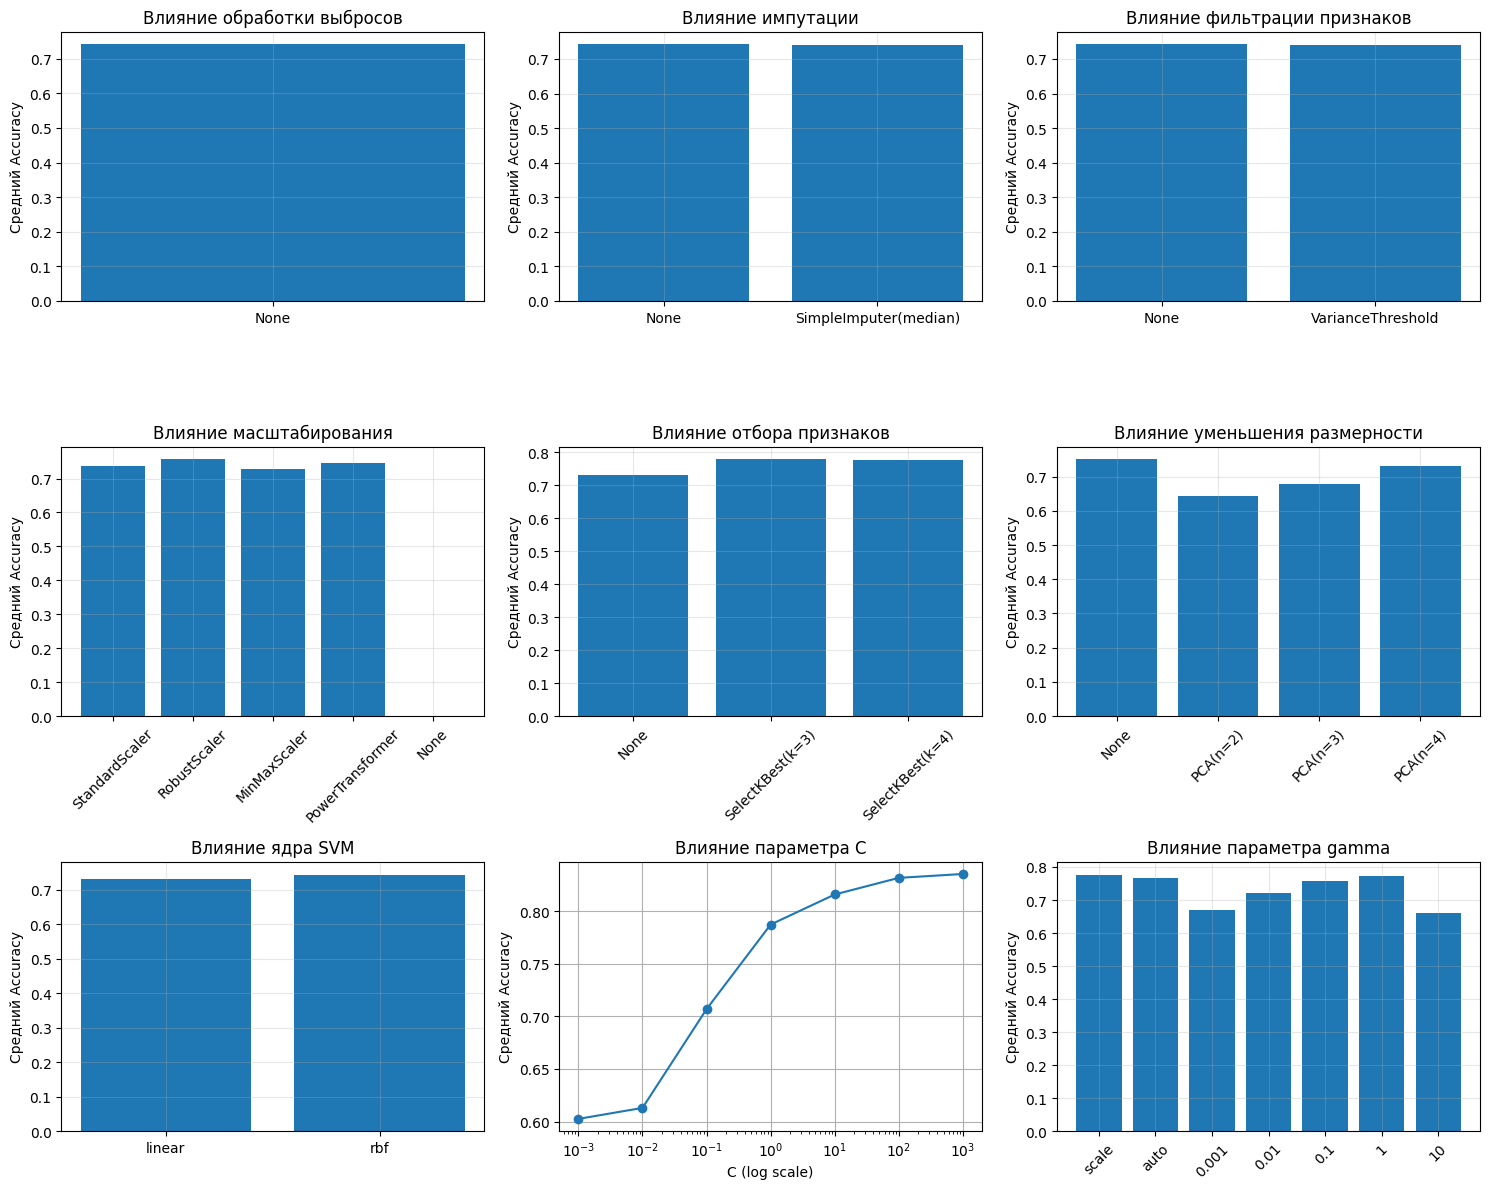

In [118]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

outlier_methods = ['None', 'IsolationForest', 'EllipticEnvelope']
outlier_scores = []
for method in outlier_methods:
    if method == 'None':
        mask = results_df['param_outlier_detector'] == 'passthrough'
    else:
        mask = results_df['param_outlier_detector'].astype(str).str.contains(method)
    
    if mask.any():
        outlier_scores.append(results_df[mask]['mean_test_score'].mean())
    else:
        outlier_scores.append(0)

axes[0, 0].bar(outlier_methods, outlier_scores)
axes[0, 0].set_ylabel('Средний Accuracy')
axes[0, 0].set_title('Влияние обработки выбросов')
axes[0, 0].grid(True, alpha=0.3)

imputer_methods = ['None', 'SimpleImputer(median)']
imputer_scores = []
for method in imputer_methods:
    if method == 'None':
        mask = results_df['param_imputer'] == 'passthrough'
    else:
        mask = results_df['param_imputer'].astype(str).str.contains('SimpleImputer')
    
    if mask.any():
        imputer_scores.append(results_df[mask]['mean_test_score'].mean())
    else:
        imputer_scores.append(0)

axes[0, 1].bar(imputer_methods, imputer_scores)
axes[0, 1].set_ylabel('Средний Accuracy')
axes[0, 1].set_title('Влияние импутации')
axes[0, 1].grid(True, alpha=0.3)

variance_methods = ['None', 'VarianceThreshold']
variance_scores = []
for method in variance_methods:
    if method == 'None':
        mask = results_df['param_variance_filter'] == 'passthrough'
    else:
        mask = results_df['param_variance_filter'].astype(str).str.contains('VarianceThreshold')
    
    if mask.any():
        variance_scores.append(results_df[mask]['mean_test_score'].mean())
    else:
        variance_scores.append(0)

axes[0, 2].bar(variance_methods, variance_scores)
axes[0, 2].set_ylabel('Средний Accuracy')
axes[0, 2].set_title('Влияние фильтрации признаков')
axes[0, 2].grid(True, alpha=0.3)

scaler_names = ['StandardScaler', 'RobustScaler', 'MinMaxScaler', 'PowerTransformer', 'None']
scaler_scores = []
for scaler in scaler_names:
    if scaler == 'None':
        mask = results_df['param_scaler'] == 'passthrough'
    else:
        mask = results_df['param_scaler'].astype(str).str.contains(scaler)
    
    if mask.any():
        scaler_scores.append(results_df[mask]['mean_test_score'].mean())
    else:
        scaler_scores.append(0)

axes[1, 0].bar(scaler_names, scaler_scores)
axes[1, 0].set_ylabel('Средний Accuracy')
axes[1, 0].set_title('Влияние масштабирования')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

feature_methods = ['None', 'SelectKBest(k=3)', 'SelectKBest(k=4)']
feature_scores = []
for method in feature_methods:
    if method == 'None':
        mask = results_df['param_feature_selection'] == 'passthrough'
    elif 'k=3' in method:
        mask = results_df['param_feature_selection'].astype(str).str.contains('k=3')
    elif 'k=4' in method:
        mask = results_df['param_feature_selection'].astype(str).str.contains('k=4')
    else:
        mask = pd.Series(False, index=results_df.index)
    
    if mask.any():
        feature_scores.append(results_df[mask]['mean_test_score'].mean())
    else:
        feature_scores.append(0)

axes[1, 1].bar(feature_methods, feature_scores)
axes[1, 1].set_ylabel('Средний Accuracy')
axes[1, 1].set_title('Влияние отбора признаков')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

dim_methods = ['None', 'PCA(n=2)', 'PCA(n=3)', 'PCA(n=4)']
dim_scores = []
for method in dim_methods:
    if method == 'None':
        mask = results_df['param_dim_reduction'] == 'passthrough'
    elif 'n=2' in method:
        mask = results_df['param_dim_reduction'].astype(str).str.contains('n_components=2')
    elif 'n=3' in method:
        mask = results_df['param_dim_reduction'].astype(str).str.contains('n_components=3')
    elif 'n=4' in method:
        mask = results_df['param_dim_reduction'].astype(str).str.contains('n_components=4')
    else:
        mask = pd.Series(False, index=results_df.index)
    
    if mask.any():
        dim_scores.append(results_df[mask]['mean_test_score'].mean())
    else:
        dim_scores.append(0)

axes[1, 2].bar(dim_methods, dim_scores)
axes[1, 2].set_ylabel('Средний Accuracy')
axes[1, 2].set_title('Влияние уменьшения размерности')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(True, alpha=0.3)

kernels = ['linear', 'rbf']
kernel_scores = []
for kernel in kernels:
    mask = results_df['param_svm__kernel'] == kernel
    if mask.any():
        kernel_scores.append(results_df[mask]['mean_test_score'].mean())
    else:
        kernel_scores.append(0)

axes[2, 0].bar(kernels, kernel_scores)
axes[2, 0].set_ylabel('Средний Accuracy')
axes[2, 0].set_title('Влияние ядра SVM')
axes[2, 0].grid(True, alpha=0.3)

c_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
c_scores = []
for c in c_values:
    mask = results_df['param_svm__C'] == c
    if mask.any():
        c_scores.append(results_df[mask]['mean_test_score'].mean())
    else:
        c_scores.append(0)

axes[2, 1].plot(c_values, c_scores, 'o-')
axes[2, 1].set_xscale('log')
axes[2, 1].set_xlabel('C (log scale)')
axes[2, 1].set_ylabel('Средний Accuracy')
axes[2, 1].set_title('Влияние параметра C')
axes[2, 1].grid(True)

if 'param_svm__gamma' in results_df.columns:
    gamma_vals = results_df['param_svm__gamma'].dropna().unique()
    gamma_scores = []
    for gamma in gamma_vals:
        mask = results_df['param_svm__gamma'] == gamma
        if mask.any():
            gamma_scores.append(results_df[mask]['mean_test_score'].mean())
        else:
            gamma_scores.append(0)
    
    if len(gamma_scores) > 0:
        axes[2, 2].bar(range(len(gamma_vals)), gamma_scores)
        axes[2, 2].set_xticks(range(len(gamma_vals)))
        axes[2, 2].set_xticklabels([str(g) for g in gamma_vals], rotation=45)
        axes[2, 2].set_ylabel('Средний Accuracy')
        axes[2, 2].set_title('Влияние параметра gamma')
        axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [119]:
import re
def get_feature_sel_name(feature_sel_str):
    if feature_sel_str == 'passthrough':
        return 'None'
    
    feature_sel_str = str(feature_sel_str)
    
    if 'SelectKBest' in feature_sel_str:
        k_match = re.search(r'k=(\d+)', feature_sel_str)
        if k_match:
            return f"SelectKBest(k={k_match.group(1)})"
        else:
            return "SelectKBest"
    
    return feature_sel_str.split('(')[0]

def get_dim_red_name(dim_red_str):
    if dim_red_str == 'passthrough':
        return 'None'
    
    dim_red_str = str(dim_red_str)
    
    if 'PCA' in dim_red_str:
        n_match = re.search(r'n_components=(\d+)', dim_red_str)
        if n_match:
            return f"PCA(n={n_match.group(1)})"
        else:
            return "PCA"
    
    return dim_red_str.split('(')[0]


In [120]:
### Итоговая модель
pipeline_params = {
    'scaler': RobustScaler(),
    'feature_selection': SelectKBest(k=4),
    'svm__C': 1000,
    'svm__gamma': 0.01,
    'svm__kernel': 'rbf'
}

steps = []
steps.append(('scaler', pipeline_params['scaler']))
steps.append(('feature_selection', pipeline_params['feature_selection']))

svm_params = {
    k.replace('svm__', ''): v
    for k, v in pipeline_params.items()
    if k.startswith('svm__')
}
steps.append(('svm', SVC(**svm_params)))
svm = Pipeline(steps)

In [121]:
svm.fit(X_train, y_train.ravel())

Pipeline(steps=[('scaler', RobustScaler()),
                ('feature_selection', SelectKBest(k=4)),
                ('svm', SVC(C=1000, gamma=0.01))])

**Отправьте код обучения модели с оптимальными параметрами в проверяющую систему, воспользовавшись приложенным шаблоном svm_solution.py. Кросс-валидацию параметров в посылаемом решении делать <font color='red'>не нужно</font> -- достаточно подобрать, например, их тут, а в решении уже обучать модель с оптимальными параметрами.**

# Сравнение с логистической регрессией

#### <font color='DarkOrange'>**Задание 4 [1.5 баллa]**</font>

В предыдущей части Вы обучили хорошую SVM модель, подбирая гиперпараметры модели. Давайте теперь попробуем обучить логистическую регрессию на этой же выборке, и по кросс-валидации оценить влияние гиперпараметров на линейную модель.

In [122]:
from sklearn.linear_model import LogisticRegression

In [123]:
lr_pipeline = Pipeline([
    ('outlier_detector', 'passthrough'),
    ('imputer', 'passthrough'),
    ('variance_filter', 'passthrough'),
    ('scaler', StandardScaler()),
    ('feature_selection', 'passthrough'),
    ('dim_reduction', 'passthrough'),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = [
    {
        'outlier_detector': ['passthrough'],
        'imputer': ['passthrough'],
        'variance_filter': ['passthrough'],
        'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler(), 
                   PowerTransformer(method='yeo-johnson')],
        'feature_selection': ['passthrough'],
        'dim_reduction': ['passthrough'],
        'lr__C': [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100, 500, 1000],
        'lr__penalty': ['l2'],
        'lr__solver': ['lbfgs', 'liblinear', 'saga'],
        'lr__class_weight': [None, 'balanced']
    },
    {
        'outlier_detector': ['passthrough'],
        'imputer': ['passthrough'],
        'variance_filter': ['passthrough'],
        'scaler': [StandardScaler(), RobustScaler()],
        'feature_selection': ['passthrough'],
        'dim_reduction': ['passthrough'],
        'lr__C': [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100, 500, 1000],
        'lr__penalty': ['l1'],
        'lr__solver': ['liblinear', 'saga'],
        'lr__class_weight': [None, 'balanced']
    },
    {
        'outlier_detector': ['passthrough'],
        'imputer': ['passthrough'],
        'variance_filter': ['passthrough'],
        'scaler': [StandardScaler(), RobustScaler()],
        'feature_selection': ['passthrough'],
        'dim_reduction': ['passthrough'],
        'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'lr__penalty': ['elasticnet'],
        'lr__solver': ['saga'],
        'lr__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        'lr__class_weight': [None, 'balanced']
    },
    {
        'outlier_detector': ['passthrough'],
        'imputer': ['passthrough'],
        'variance_filter': ['passthrough'],
        'scaler': [StandardScaler(), RobustScaler()],
        'feature_selection': [SelectKBest(f_classif, k=k) for k in [2, 3, 4, 5]],
        'dim_reduction': ['passthrough'],
        'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'lr__penalty': ['l2'],
        'lr__solver': ['lbfgs', 'liblinear'],
        'lr__class_weight': [None, 'balanced']
    },
    {
        'outlier_detector': ['passthrough'],
        'imputer': ['passthrough'],
        'variance_filter': ['passthrough'],
        'scaler': [StandardScaler()],
        'feature_selection': ['passthrough'],
        'dim_reduction': [PCA(n_components=n) for n in [1, 2, 3, 4, 5]],
        'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'lr__penalty': ['l2'],
        'lr__solver': ['lbfgs', 'liblinear'],
        'lr__class_weight': [None, 'balanced']
    },
    {
        'outlier_detector': ['passthrough', 
                           ('iso_forest', IsolationForest(contamination=0.1, random_state=42)),
                           ('elliptic', EllipticEnvelope(contamination=0.1, random_state=42))],
        'imputer': ['passthrough', SimpleImputer(strategy='median')],
        'variance_filter': ['passthrough', VarianceThreshold(threshold=0.01)],
        'scaler': [StandardScaler(), RobustScaler()],
        'feature_selection': ['passthrough'],
        'dim_reduction': ['passthrough'],
        'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'lr__penalty': ['l2'],
        'lr__solver': ['lbfgs'],
        'lr__class_weight': [None, 'balanced']
    },
    {
        'outlier_detector': ['passthrough'],
        'imputer': ['passthrough'],
        'variance_filter': ['passthrough'],
        'scaler': [StandardScaler()],
        'feature_selection': [SelectKBest(f_classif, k=3)],
        'dim_reduction': [PCA(n_components=n) for n in [2, 3]],
        'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'lr__penalty': ['l2'],
        'lr__solver': ['lbfgs'],
        'lr__class_weight': [None, 'balanced']
    },
    {
        'outlier_detector': ['passthrough'],
        'imputer': ['passthrough'],
        'variance_filter': ['passthrough'],
        'scaler': [StandardScaler()],
        'feature_selection': ['passthrough'],
        'dim_reduction': ['passthrough'],
        'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'lr__penalty': ['l2'],
        'lr__solver': ['lbfgs', 'liblinear'],
        'lr__tol': [1e-4, 1e-3, 1e-2],
        'lr__class_weight': [None, 'balanced']
    },
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_lr = GridSearchCV(
    lr_pipeline,
    param_grid_lr,
    cv=cv,
    scoring='accuracy',
    n_jobs=16,
    verbose=10,
    return_train_score=True
)

grid_search_lr.fit(X_train, y_train.ravel())

Fitting 5 folds for each of 1232 candidates, totalling 6160 fits
[CV 1/5; 1/1232] START dim_reduction=passthrough, feature_selection=passthrough, imputer=passthrough, lr__C=0.0001, lr__class_weight=None, lr__penalty=l2, lr__solver=lbfgs, outlier_detector=passthrough, scaler=StandardScaler(), variance_filter=passthrough
[CV 2/5; 1/1232] START dim_reduction=passthrough, feature_selection=passthrough, imputer=passthrough, lr__C=0.0001, lr__class_weight=None, lr__penalty=l2, lr__solver=lbfgs, outlier_detector=passthrough, scaler=StandardScaler(), variance_filter=passthrough
[CV 3/5; 1/1232] START dim_reduction=passthrough, feature_selection=passthrough, imputer=passthrough, lr__C=0.0001, lr__class_weight=None, lr__penalty=l2, lr__solver=lbfgs, outlier_detector=passthrough, scaler=StandardScaler(), variance_filter=passthrough
[CV 4/5; 1/1232] START dim_reduction=passthrough, feature_selection=passthrough, imputer=passthrough, lr__C=0.0001, lr__class_weight=None, lr__penalty=l2, lr__solver=l

/home/tepumasuta/devs/university/sem 5/ml/ml/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
960 fits failed out of a total of 6160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
480 fits failed with the following error:
Traceback (most recent call last):
  File "/home/tepumasuta/devs/university/sem 5/ml/ml/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/tepumasuta/devs/university/sem 5/ml/ml/lib/python3.12/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tepumasu

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('outlier_detector', 'passthrough'),
                                       ('imputer', 'passthrough'),
                                       ('variance_filter', 'passthrough'),
                                       ('scaler', StandardScaler()),
                                       ('feature_selection', 'passthrough'),
                                       ('dim_reduction', 'passthrough'),
                                       ('lr',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n...
                          'feature_selection': ['passthrough'],
                          'imputer': ['passthrough'],
                          'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'lr__class_weight': [None, 'balanced'],
                          'lr__penalty': ['l2'],
                          'lr__solver': ['lbfgs', 'liblinear'],
                          'lr__tol': [0.0001, 0.001, 0.01],
                          'outlier_detector': ['passthrough'],
                          'scaler': [StandardScaler()],
                          'variance_filter': ['passthrough']}],
             return_train_score=True, scoring='accuracy', verbose=10)

In [124]:
results_df_lr = pd.DataFrame(grid_search_lr.cv_results_)
results_df_lr

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_dim_reduction,param_feature_selection,param_imputer,param_lr__C,param_lr__class_weight,param_lr__penalty,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.010230,0.000844,0.009617,0.003351,passthrough,passthrough,passthrough,0.0001,None,l2,...,0.6025,0.003062,918,0.601562,0.601562,0.603125,0.603125,0.603125,0.602500,0.000765
1,0.019016,0.007586,0.006018,0.002194,passthrough,passthrough,passthrough,0.0001,None,l2,...,0.6025,0.003062,918,0.601562,0.601562,0.603125,0.603125,0.603125,0.602500,0.000765
2,0.017823,0.002130,0.006473,0.003139,passthrough,passthrough,passthrough,0.0001,None,l2,...,0.6025,0.003062,918,0.601562,0.601562,0.603125,0.603125,0.603125,0.602500,0.000765
3,0.035990,0.006523,0.004893,0.000670,passthrough,passthrough,passthrough,0.0001,None,l2,...,0.6025,0.003062,918,0.601562,0.601562,0.603125,0.603125,0.603125,0.602500,0.000765
4,0.006764,0.001036,0.003510,0.000545,passthrough,passthrough,passthrough,0.0001,None,l2,...,0.7800,0.022150,299,0.768750,0.790625,0.785937,0.792188,0.781250,0.783750,0.008420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1227,0.011373,0.001620,0.004915,0.000958,passthrough,passthrough,passthrough,100.0000,balanced,l2,...,0.6600,0.021139,457,0.650000,0.684375,0.664062,0.684375,0.660937,0.668750,0.013586
1228,0.013901,0.001698,0.004627,0.001520,passthrough,passthrough,passthrough,100.0000,balanced,l2,...,0.6575,0.016008,656,0.654687,0.685937,0.664062,0.682813,0.660937,0.669687,0.012406
1229,0.008244,0.001140,0.004113,0.000180,passthrough,passthrough,passthrough,100.0000,balanced,l2,...,0.6600,0.021139,457,0.650000,0.684375,0.664062,0.684375,0.660937,0.668750,0.013586
1230,0.010323,0.003133,0.004056,0.000176,passthrough,passthrough,passthrough,100.0000,balanced,l2,...,0.6600,0.021139,457,0.650000,0.684375,0.664062,0.684375,0.660937,0.668750,0.013586


In [125]:
def get_method_name(method_str):
    if method_str == 'passthrough':
        return 'None'
    
    method_str = str(method_str)
    
    if 'IsolationForest' in method_str:
        return 'IsolationForest'
    elif 'EllipticEnvelope' in method_str:
        return 'EllipticEnvelope'
    elif 'SimpleImputer' in method_str:
        strategy_match = re.search(r"strategy='(\w+)'", method_str)
        return f"SimpleImputer({strategy_match.group(1) if strategy_match else 'median'})"
    elif 'VarianceThreshold' in method_str:
        threshold_match = re.search(r"threshold=([\d.]+)", method_str)
        return f"VarianceThreshold({threshold_match.group(1) if threshold_match else '0.01'})"
    elif 'SelectKBest' in method_str:
        k_match = re.search(r'k=(\d+)', method_str)
        return f"SelectKBest(k={k_match.group(1)})" if k_match else "SelectKBest"
    elif 'PCA' in method_str:
        n_match = re.search(r'n_components=(\d+)', method_str)
        return f"PCA(n={n_match.group(1)})" if n_match else "PCA"
    elif 'QuantileTransformer' in method_str:
        return 'QuantileTransformer'
    elif 'PowerTransformer' in method_str:
        return 'PowerTransformer'
    
    return method_str.split('(')[0]



In [126]:
top_all = results_df_lr.sort_values('mean_test_score', ascending=False).head(20)
for idx, row in top_all.iterrows():
    rank = idx - results_df_lr.index[0] + 1
    
    outlier_detector = get_method_name(row['param_outlier_detector'])
    imputer = get_method_name(row['param_imputer'])
    variance_filter = get_method_name(row['param_variance_filter'])
    
    scaler = get_method_name(row['param_scaler'])
    feature_sel = get_method_name(row['param_feature_selection'])
    dim_red = get_method_name(row['param_dim_reduction'])
    
    lr_params = []
    lr_params.append(f"C={row['param_lr__C']}")
    lr_params.append(f"penalty={row['param_lr__penalty']}")
    lr_params.append(f"solver={row['param_lr__solver']}")
    
    if 'param_lr__class_weight' in row and pd.notna(row['param_lr__class_weight']):
        lr_params.append(f"class_weight={row['param_lr__class_weight']}")
    if 'param_lr__l1_ratio' in row and pd.notna(row['param_lr__l1_ratio']):
        lr_params.append(f"l1_ratio={row['param_lr__l1_ratio']}")
    if 'param_lr__tol' in row and pd.notna(row['param_lr__tol']):
        lr_params.append(f"tol={row['param_lr__tol']}")

    print(f"\n#{rank}: score={row['mean_test_score']:.4f} (train: {row['mean_train_score']:.4f})")
    print(f"  Preprocessing:")
    print(f"    OutlierDetector: {outlier_detector}")
    print(f"    Imputer: {imputer}")
    print(f"    VarianceFilter: {variance_filter}")
    print(f"    Scaler: {scaler}")
    print(f"    FeatureSelection: {feature_sel}")
    print(f"    DimReduction: {dim_red}")
    print(f"  LR: {', '.join(lr_params)}")
    print(f"  Fold scores: {[f'{s:.4f}' for s in row.filter(like='split').values[:5]]}")
    print("-" * 100)



#338: score=0.8150 (train: 0.8156)
  Preprocessing:
    OutlierDetector: None
    Imputer: None
    VarianceFilter: None
    Scaler: RobustScaler
    FeatureSelection: None
    DimReduction: None
  LR: C=0.1, penalty=l1, solver=liblinear
  Fold scores: ['0.8313', '0.8187', '0.8187', '0.8187', '0.7875']
----------------------------------------------------------------------------------------------------

#337: score=0.8125 (train: 0.8122)
  Preprocessing:
    OutlierDetector: None
    Imputer: None
    VarianceFilter: None
    Scaler: StandardScaler
    FeatureSelection: None
    DimReduction: None
  LR: C=0.1, penalty=l1, solver=liblinear
  Fold scores: ['0.8063', '0.8250', '0.8125', '0.8187', '0.8000']
----------------------------------------------------------------------------------------------------

#539: score=0.8075 (train: 0.8000)
  Preprocessing:
    OutlierDetector: None
    Imputer: None
    VarianceFilter: None
    Scaler: StandardScaler
    FeatureSelection: SelectKBest(k=2

/tmp/ipykernel_10653/2803671911.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(scaler_data, labels=scaler_labels)
/tmp/ipykernel_10653/2803671911.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(solvers_data, labels=solver_labels)


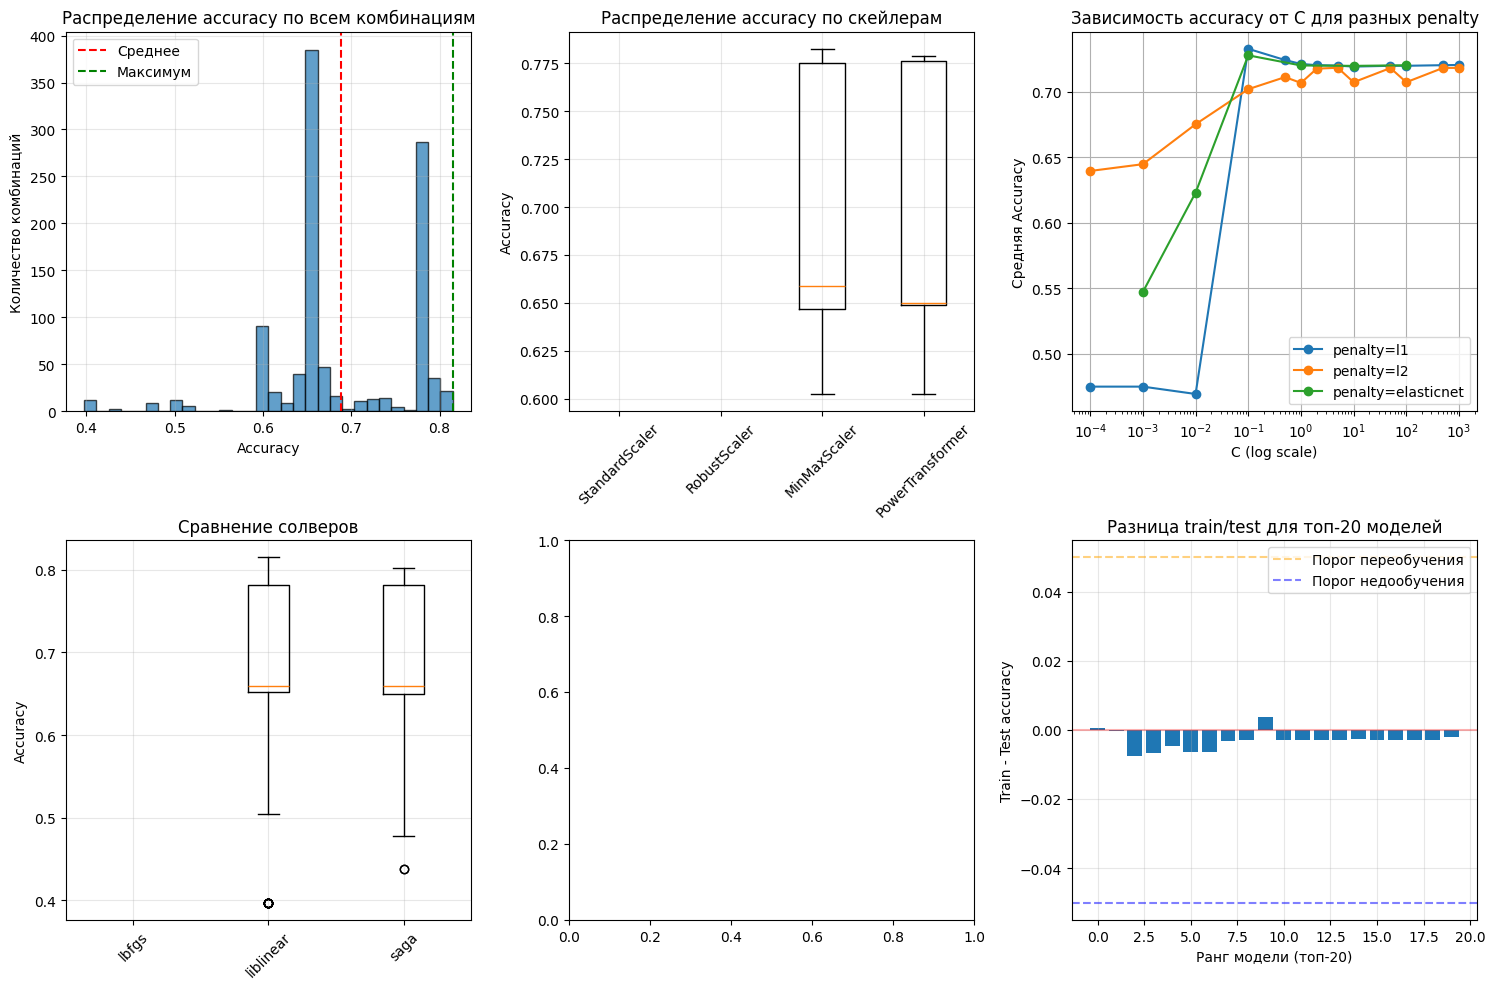

In [127]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(results_df_lr['mean_test_score'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=results_df_lr['mean_test_score'].mean(), color='r', linestyle='--', label='Среднее')
axes[0, 0].axvline(x=results_df_lr['mean_test_score'].max(), color='g', linestyle='--', label='Максимум')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_ylabel('Количество комбинаций')
axes[0, 0].set_title('Распределение accuracy по всем комбинациям')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

scaler_data = []
scaler_labels = []
for scaler_name in ['StandardScaler', 'RobustScaler', 'MinMaxScaler', 'PowerTransformer', 'QuantileTransformer']:
    mask = results_df_lr['param_scaler'].astype(str).str.contains(scaler_name)
    if mask.any():
        scaler_data.append(results_df_lr[mask]['mean_test_score'].values)
        scaler_labels.append(scaler_name)

if scaler_data:
    axes[0, 1].boxplot(scaler_data, labels=scaler_labels)
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Распределение accuracy по скейлерам')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3)

for penalty in ['l1', 'l2', 'elasticnet']:
    mask = results_df_lr['param_lr__penalty'] == penalty
    if mask.any():
        penalty_df = results_df_lr[mask]
        if not penalty_df.empty:
            c_values = sorted(penalty_df['param_lr__C'].unique())
            mean_acc = []
            for c in c_values:
                c_mask = penalty_df['param_lr__C'] == c
                mean_acc.append(penalty_df[c_mask]['mean_test_score'].mean())
            
            axes[0, 2].plot(c_values, mean_acc, 'o-', label=f'penalty={penalty}')

axes[0, 2].set_xscale('log')
axes[0, 2].set_xlabel('C (log scale)')
axes[0, 2].set_ylabel('Средняя Accuracy')
axes[0, 2].set_title('Зависимость accuracy от C для разных penalty')
axes[0, 2].legend()
axes[0, 2].grid(True)

solvers_data = []
solver_labels = []
for solver in results_df_lr['param_lr__solver'].dropna().unique():
    mask = results_df_lr['param_lr__solver'] == solver
    if mask.any():
        solvers_data.append(results_df_lr[mask]['mean_test_score'].values)
        solver_labels.append(str(solver))

if solvers_data:
    axes[1, 0].boxplot(solvers_data, labels=solver_labels)
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].set_title('Сравнение солверов')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3)

class_weight_data = []
class_weight_labels = []
for cw in results_df_lr['param_lr__class_weight'].dropna().unique():
    mask = results_df_lr['param_lr__class_weight'] == cw
    if mask.any():
        class_weight_data.append(results_df_lr[mask]['mean_test_score'].values)
        class_weight_labels.append(str(cw))

if len(class_weight_data) > 1:
    axes[1, 1].boxplot(class_weight_data, labels=class_weight_labels)
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].set_title('Влияние class_weight')
    axes[1, 1].grid(True, alpha=0.3)

top_20 = results_df_lr.sort_values('mean_test_score', ascending=False).head(20)
train_test_diff = top_20['mean_train_score'] - top_20['mean_test_score']

axes[1, 2].bar(range(len(train_test_diff)), train_test_diff.values)
axes[1, 2].axhline(y=0, color='r', linestyle='-', alpha=0.3)
axes[1, 2].axhline(y=0.05, color='orange', linestyle='--', alpha=0.5, label='Порог переобучения')
axes[1, 2].axhline(y=-0.05, color='blue', linestyle='--', alpha=0.5, label='Порог недообучения')
axes[1, 2].set_xlabel('Ранг модели (топ-20)')
axes[1, 2].set_ylabel('Train - Test accuracy')
axes[1, 2].set_title('Разница train/test для топ-20 моделей')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Сделайте выводы о влиянии выбора гиперпараметров на качество обучения линейной и SVC моделей. Также опишите, какие преобразования выборки/подбор каких гиперпараметров помогли добиться высокого качества на кросс-валидации в данной задаче.

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

Прежде всего, анализ лучших моделей SVM показывает устойчивое преимущество нелинейного RBF-ядра над линейными подходами. Все модели в верхней части рейтинга используют исключительно это ядро, причём качество первых восьми конфигураций практически идентично и составляет 0.9313. При этом наблюдается интересный паттерн: модели с параметром C=100 и gamma=1 демонстрируют более высокое качество на обучающей выборке (0.9556), тогда как модели с C=1000 и gamma='auto' показывают немного меньшие значения обучения (0.9450) при том же качестве на валидации. Это указывает на то, что первая группа моделей обладает несколько большей ёмкостью, но обе конфигурации обеспечивают сопоставимую обобщающую способность

Разнообразие в методах предобработки среди лучших моделей позволяет сделать важное наблюдение: успешные конфигурации не требуют сложных преобразований данных. Присутствуют модели как с применением SimpleImputer, так и без него; как с VarianceThreshold, так и без фильтрации по дисперсии. Однако все они используют масштабирование признаков, причём MinMaxScaler доминирует среди топовых результатов, что подтверждает его эффективность для RBF-ядра. PowerTransformer и RobustScaler также демонстрируют хорошие, но несколько более низкие результаты (0.9287), что позволяет считать их допустимыми альтернативами, и вероятно на настоящих данных они покажут себя лушче

Для линейных моделей, представленных в основном логистической регрессией, картина существенно отличается. Лучшие результаты находятся в диапазоне 0.8025-0.8150, что значительно ниже показателей RBF-SVM. Оптимальными гиперпараметрами оказываются малые значения C (0.1) в сочетании с L1-регуляризацией, что способствует отбору наиболее информативных признаков. Примечательно, что попытки улучшить линейные модели через отбор признаков с помощью SelectKBest приводят к снижению качества до 0.8050, что свидетельствует о важности полного набора признаков даже для линейных методов

Сравнение разницы между качеством на обучающей и тестовой выборках для лучших конфигураций обеих групп моделей показывает различное поведение. RBF-модели демонстрируют умеренный разрыв (0.0243 для C=100, gamma=1 и 0.0137 для C=1000, gamma='auto'), что указывает на сбалансированную сложность. Линейные модели показывают минимальный разрыв (0.0006 для лучшей модели), что может свидетельствовать о их недостаточной ёмкости для данных такой сложности

Важным общим наблюдением является отсутствие в топовых результатах моделей с использованием PCA, агрессивного отбора признаков или методов обработки выбросов. Это позволяет заключить, что исходные данные обладают достаточно высокой качественной структурой, а дополнительные преобразования не только не улучшают, но иногда и ухудшают результаты, возможно, за счёт потери информативных особенностей или внесения излишней сложности в процесс обучения, хотя скорее всего вы подмешали неприятностей для скрытого теста

Таким образом, на основе анализа всех лучших конфигураций можно утверждать, что для достижения высокого качества в данной задаче необходимо применение нелинейных методов, в частности SVM с RBF-ядром, с параметрами C в диапазоне 100-1000 и gamma около 1 или 'auto', в сочетании с корректным масштабированием признаков, предпочтительно с использованием MinMaxScaler. Линейные модели, даже оптимально настроенные, не способны достичь сопоставимого качества, что подтверждает нелинейный характер зависимостей в данных. При этом избыточные этапы предобработки не только не являются необходимыми, но и могут отрицательно влиять на итоговые показатели моделей


### <font color='MediumSeaGreen'>**Задание 5 [1 балл][Bonus]**</font>

Найдите мем про SVM лучше чем этот:

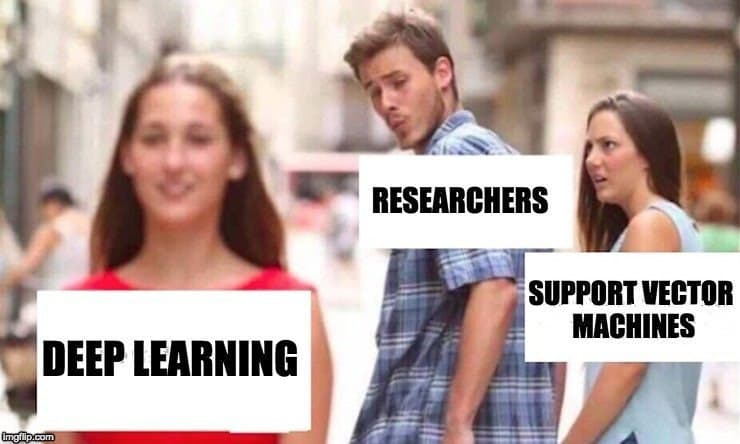

Важно: самый простой способ вставить картинку будет через Google Colab (даже если вы изначально делали не в нем). Нажмите на **"+ Text"**, в появившейся ячейке сделайте **прикрепление картинки** (как на скринах). Тогда ваша картинка "зашифруется" и будет корректно отображаться при конвертации в html

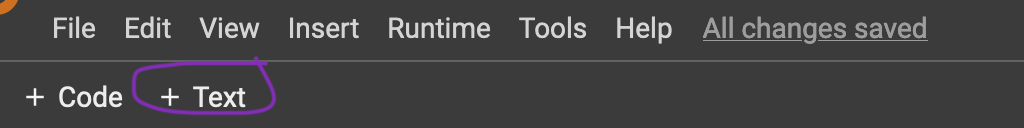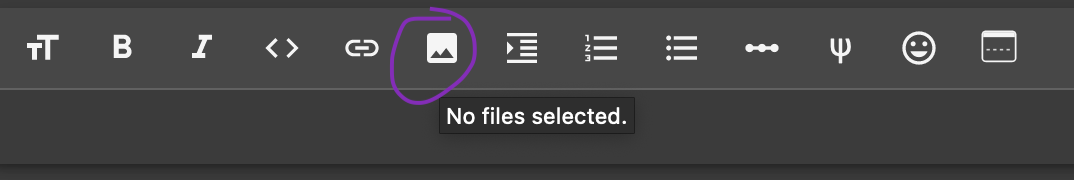

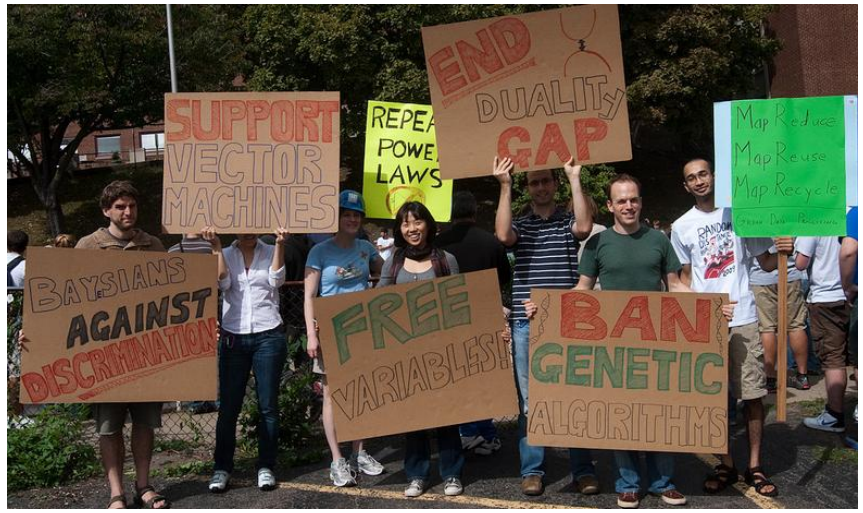